# Neural Network — Fashion MNIST Classification

**Dataset:** Fashion MNIST (built into Keras)  
**Task:** Multi-class image classification (10 clothing categories)  
**Approach:** Build a baseline model → evaluate → improve with regularization techniques

### Dataset Features

| Property | Value |
|----------|-------|
| Images | 70,000 (60,000 train / 10,000 test) |
| Image size | 28 × 28 pixels, grayscale |
| Classes | 10 clothing categories |
| Pixel range | 0–255 |

| Label | Class |
|-------|-------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: False


## 2. Load Dataset

In [2]:
(X_train_raw, y_train), (X_test_raw, y_test) = fashion_mnist.load_data()

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('Train images:', X_train_raw.shape)
print('Test images: ', X_test_raw.shape)
print('Train labels:', y_train.shape)
print('Pixel range: ', X_train_raw.min(), '–', X_train_raw.max())

Train images: (60000, 28, 28)
Test images:  (10000, 28, 28)
Train labels: (60000,)
Pixel range:  0 – 255


## 3. Exploratory Data Analysis

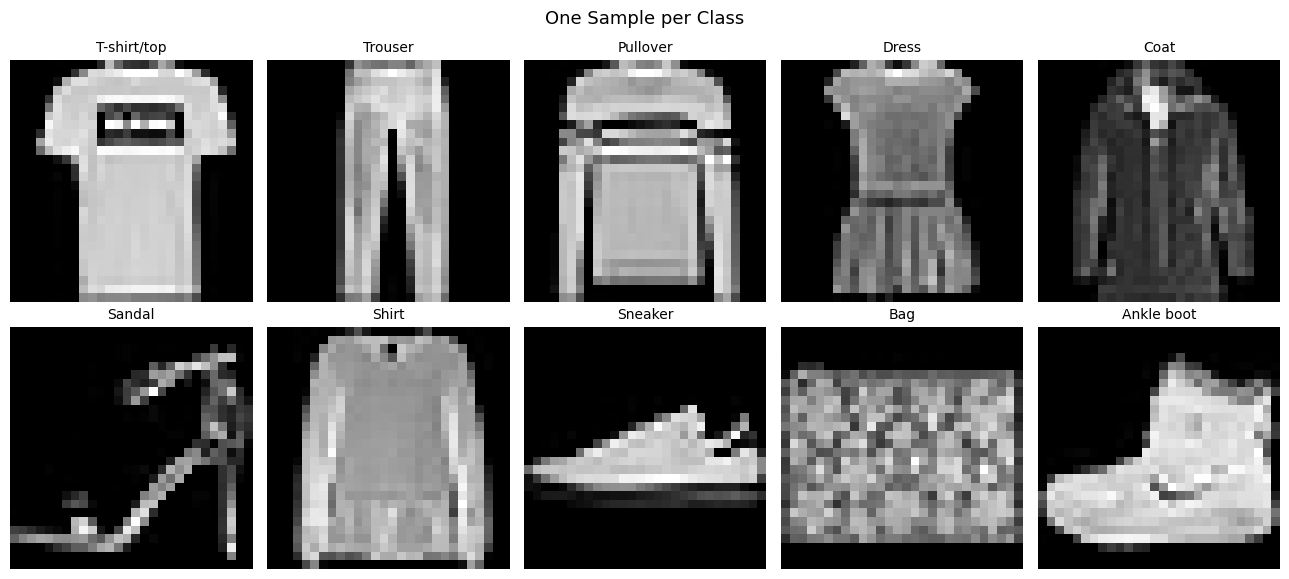

In [3]:
# Sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train_raw[idx], cmap='gray')
    ax.set_title(CLASS_NAMES[i], fontsize=10)
    ax.axis('off')
plt.suptitle('One Sample per Class', fontsize=13)
plt.tight_layout()
plt.show()

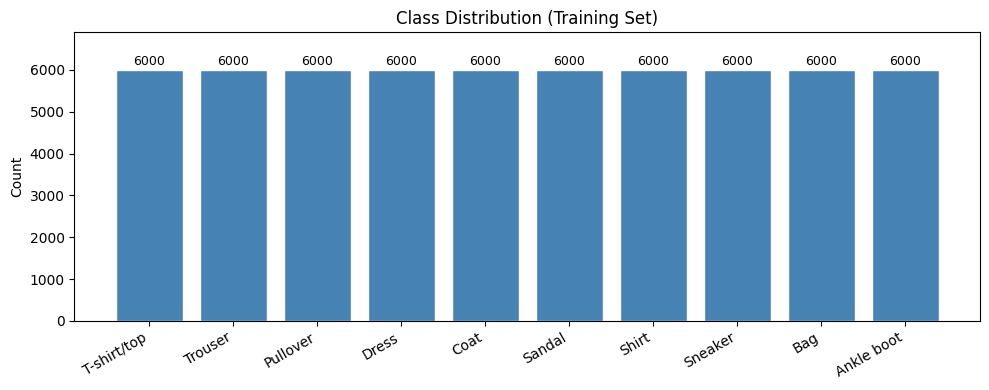

In [5]:
# Class distribution
unique, counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='white')
ax.set_title('Class Distribution (Training Set)')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

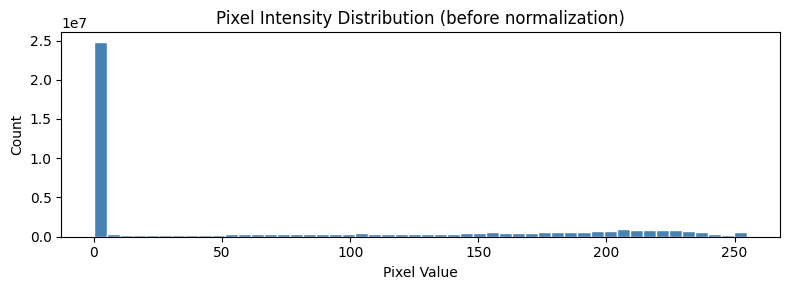

In [6]:
# Pixel intensity distribution
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(X_train_raw.flatten(), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Pixel Intensity Distribution (before normalization)')
ax.set_xlabel('Pixel Value')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Three steps before feeding data into the network:

1. **Normalize** pixel values from [0, 255] to [0, 1] — keeps gradients stable during training
2. **Flatten** each 28×28 image into a 784-element vector — Dense layers expect 1D input
3. **One-hot encode** labels — required for `categorical_crossentropy` loss

In [21]:
# Normalize
X_train = X_train_raw / 255.0
X_test  = X_test_raw  / 255.0

# Flatten: (60000, 28, 28) → (60000, 784)
X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

# One-hot encode labels
y_train_ohe = keras.utils.to_categorical(y_train, num_classes=10)
y_test_ohe  = keras.utils.to_categorical(y_test,  num_classes=10)

print('X_train_flat:', X_train_flat.shape)
print('X_test_flat: ', X_test_flat.shape)
print('y_train_ohe: ', y_train_ohe.shape)
print('Pixel range after normalization:', X_train_flat.min(), '–', X_train_flat.max())

X_train_flat: (60000, 784)
X_test_flat:  (10000, 784)
y_train_ohe:  (60000, 10)
Pixel range after normalization: 0.0 – 1.0


## 5. Baseline Model

A simple 2-layer fully connected network — no regularization, no tricks.

```
Input (784)
  → Dense(128, ReLU)
  → Dense(10, Softmax)
```

This gives us a performance baseline to beat in Section 7.

In [9]:
tf.random.set_seed(42)

baseline = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10,  activation='softmax')
], name='Baseline')

baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline.summary()

Model: "Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_base = baseline.fit(
    X_train_flat, y_train_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9330 - loss: 0.1872 - val_accuracy: 0.8863 - val_loss: 0.3316
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9347 - loss: 0.1827 - val_accuracy: 0.8862 - val_loss: 0.3325
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9370 - loss: 0.1784 - val_accuracy: 0.8857 - val_loss: 0.3423
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9385 - loss: 0.1732 - val_accuracy: 0.8850 - val_loss: 0.3463
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9399 - loss: 0.1693 - val_accuracy: 0.8847 - val_loss: 0.3520
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9421 - loss: 0.1642 - val_accuracy: 0.8852 - val_loss: 0.3556
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9431 - loss: 0.1605 - val_accuracy: 0.8852 - val_loss: 0.3574
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9446 - loss: 0.1565 - val_accuracy: 0.

## 6. Evaluate Baseline

In [23]:
def plot_history(histories, labels):
    """Plot training vs validation loss and accuracy for one or more models."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = ['steelblue', 'darkorange', 'mediumseagreen']

    for hist, label, color in zip(histories, labels, colors):
        axes[0].plot(hist.history['loss'],     color=color, label=f'{label} train')
        axes[0].plot(hist.history['val_loss'], color=color, linestyle='--', label=f'{label} val')
        axes[1].plot(hist.history['accuracy'],     color=color, label=f'{label} train')
        axes[1].plot(hist.history['val_accuracy'], color=color, linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Categorical Crossentropy')
    axes[0].legend()

    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

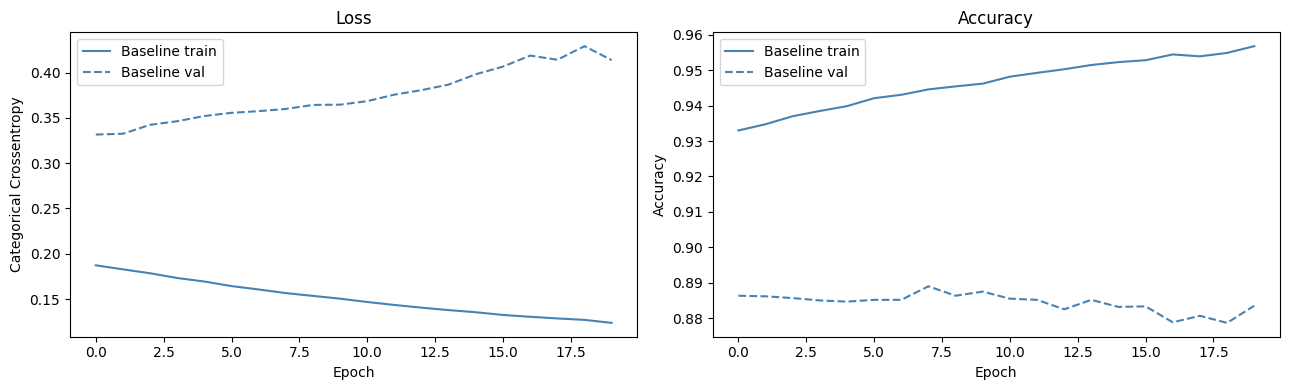

In [24]:
plot_history([history_base], ['Baseline'])

In [25]:
loss_base, acc_base = baseline.evaluate(X_test_flat, y_test_ohe, verbose=0)
print(f'Baseline — Test Loss: {loss_base:.4f}  |  Test Accuracy: {acc_base:.4f}')

Baseline — Test Loss: 0.4419  |  Test Accuracy: 0.8792


In [26]:
y_pred_base = np.argmax(baseline.predict(X_test_flat, verbose=0), axis=1)

print('Classification Report — Baseline')
print(classification_report(y_test, y_pred_base, target_names=CLASS_NAMES))

Classification Report — Baseline
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.84      0.83      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.81      0.77      0.79      1000
       Dress       0.86      0.91      0.88      1000
        Coat       0.81      0.81      0.81      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.72      0.70      0.71      1000
     Sneaker       0.96      0.88      0.92      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.88      0.99      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



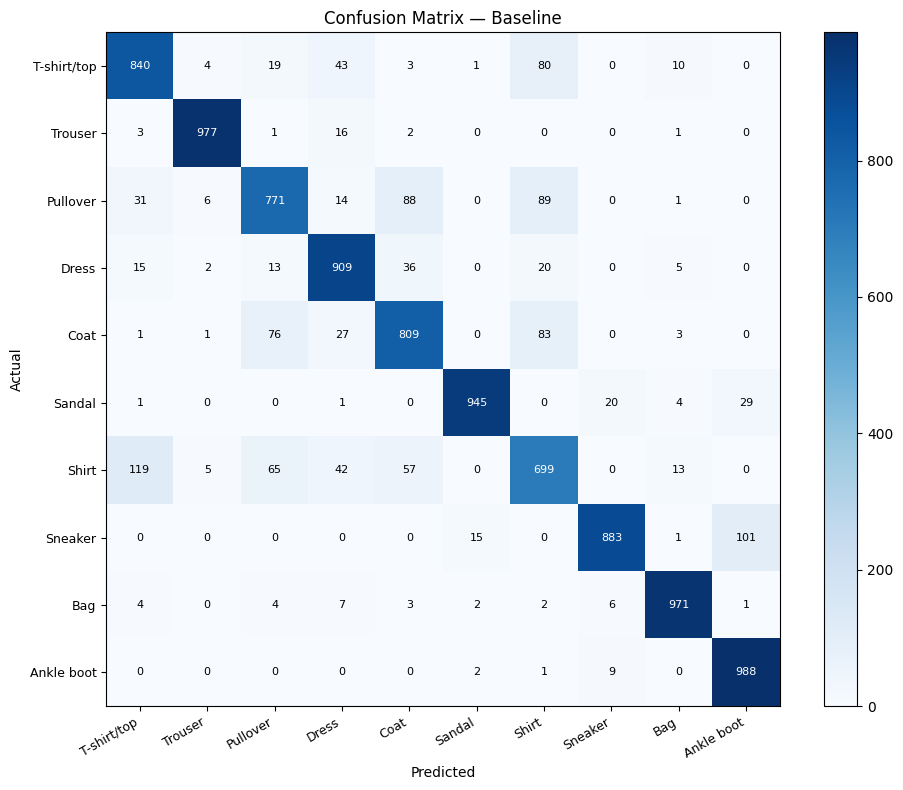

In [27]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)

    # Annotate each cell with the count
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                    color='white' if cm[i, j] > thresh else 'black')

    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_base, 'Confusion Matrix — Baseline')

## 7. Improved Model

The baseline likely shows a gap between training and validation accuracy — a sign of **overfitting**.  
We address this with four improvements:

| Technique | Purpose |
|-----------|--------|
| **Deeper network** | More capacity to learn complex patterns |
| **Batch Normalization** | Stabilizes activations, speeds up training |
| **Dropout** | Randomly disables neurons during training to prevent overfitting |
| **ReduceLROnPlateau** | Reduces learning rate when validation loss stops improving |
| **EarlyStopping** | Stops training when validation loss stops improving, restores best weights |

```
Input (784)
  → Dense(256, ReLU) → BatchNorm → Dropout(0.4)
  → Dense(128, ReLU) → BatchNorm → Dropout(0.3)
  → Dense(64,  ReLU) → BatchNorm → Dropout(0.2)
  → Dense(10,  Softmax)
```

In [28]:
tf.random.set_seed(42)

improved = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
], name='Improved')

improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved.summary()

Model: "Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [29]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_imp = improved.fit(
    X_train_flat, y_train_ohe,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7667 - loss: 0.6714 - val_accuracy: 0.8427 - val_loss: 0.4239 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8259 - loss: 0.4886 - val_accuracy: 0.8515 - val_loss: 0.4124 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8404 - loss: 0.4475 - val_accuracy: 0.8415 - val_loss: 0.4208 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8469 - loss: 0.4279 - val_accuracy: 0.8533 - val_loss: 0.3872 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8497 - loss: 0.4165 - val_accuracy: 0.8552 - val_loss: 0.3933 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8573 - loss: 0.3997 - val_accuracy: 0.8687 - val_loss: 0.3575 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8571 - loss: 0.3931 - 

## 8. Evaluate Improved Model

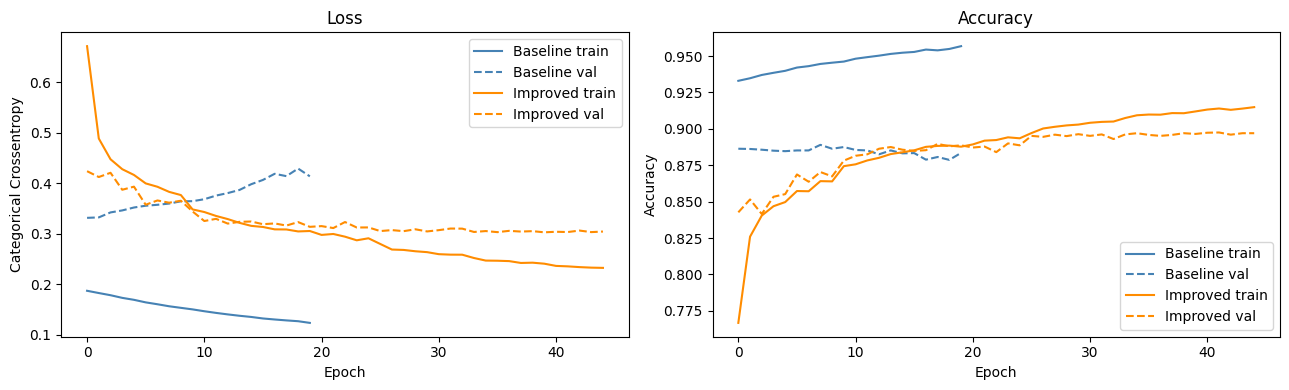

In [30]:
plot_history([history_base, history_imp], ['Baseline', 'Improved'])

In [31]:
loss_imp, acc_imp = improved.evaluate(X_test_flat, y_test_ohe, verbose=0)
print(f'Improved  — Test Loss: {loss_imp:.4f}  |  Test Accuracy: {acc_imp:.4f}')
print(f'Baseline  — Test Loss: {loss_base:.4f}  |  Test Accuracy: {acc_base:.4f}')
print(f'Improvement: +{(acc_imp - acc_base)*100:.2f}%')

Improved  — Test Loss: 0.3224  |  Test Accuracy: 0.8906
Baseline  — Test Loss: 0.4419  |  Test Accuracy: 0.8792
Improvement: +1.14%


In [32]:
y_pred_imp = np.argmax(improved.predict(X_test_flat, verbose=0), axis=1)

print('Classification Report — Improved')
print(classification_report(y_test, y_pred_imp, target_names=CLASS_NAMES))

Classification Report — Improved
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.81      0.82      0.82      1000
       Dress       0.89      0.90      0.89      1000
        Coat       0.79      0.83      0.81      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.74      0.67      0.70      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



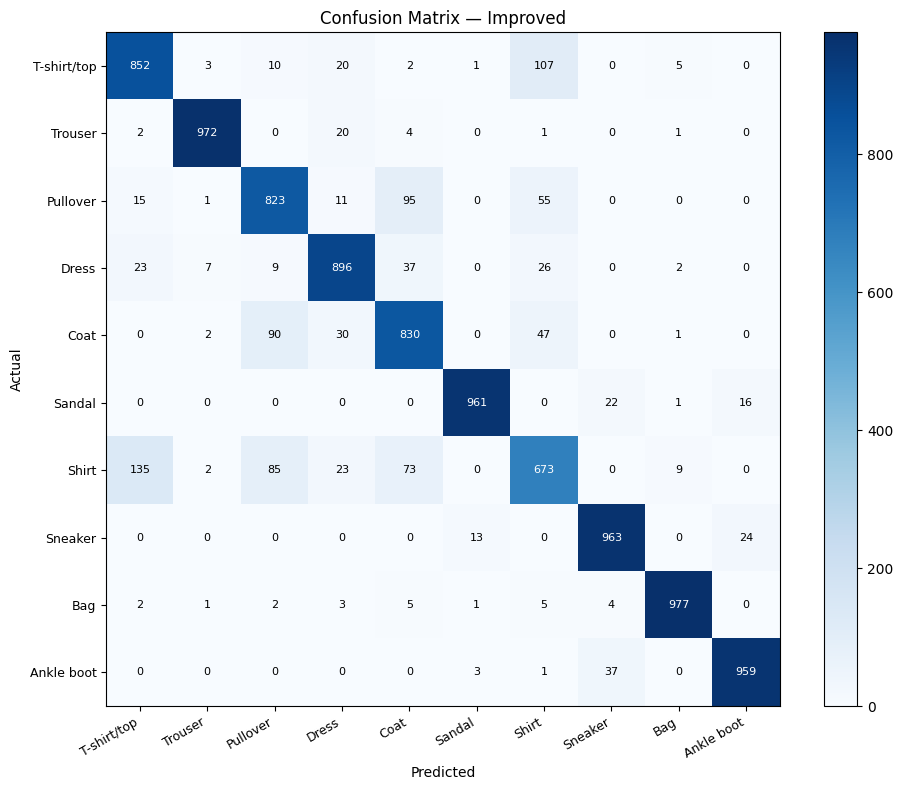

In [33]:
plot_confusion_matrix(y_test, y_pred_imp, 'Confusion Matrix — Improved')

## 9. Model Comparison

In [34]:
results = pd.DataFrame({
    'Model':        ['Baseline', 'Improved'],
    'Parameters':   [baseline.count_params(), improved.count_params()],
    'Test Loss':    [round(loss_base, 4), round(loss_imp, 4)],
    'Test Accuracy':[round(acc_base,  4), round(acc_imp,  4)],
})
results

,Model,Parameters,Test Loss,Test Accuracy
0,Baseline,101770,0.4419,0.8792
1,Improved,244554,0.3224,0.8906


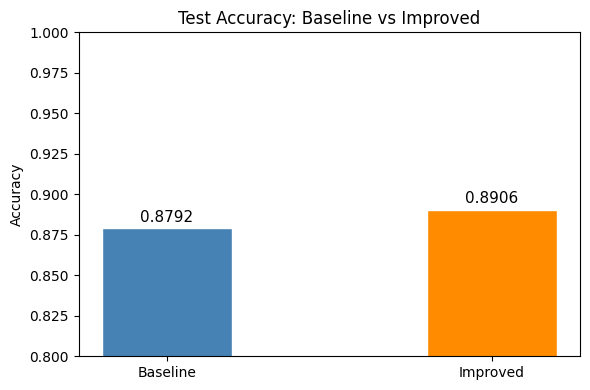

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Baseline', 'Improved'],
              [acc_base, acc_imp],
              color=['steelblue', 'darkorange'], edgecolor='white', width=0.4)
ax.set_ylim(0.8, 1.0)
ax.set_title('Test Accuracy: Baseline vs Improved')
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, [acc_base, acc_imp]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 10. Error Analysis

Looking at misclassified images helps identify which classes are inherently confusing  
(e.g., Shirt vs T-shirt/top, Pullover vs Coat).

Misclassified: 1094 / 10000 (10.9%)


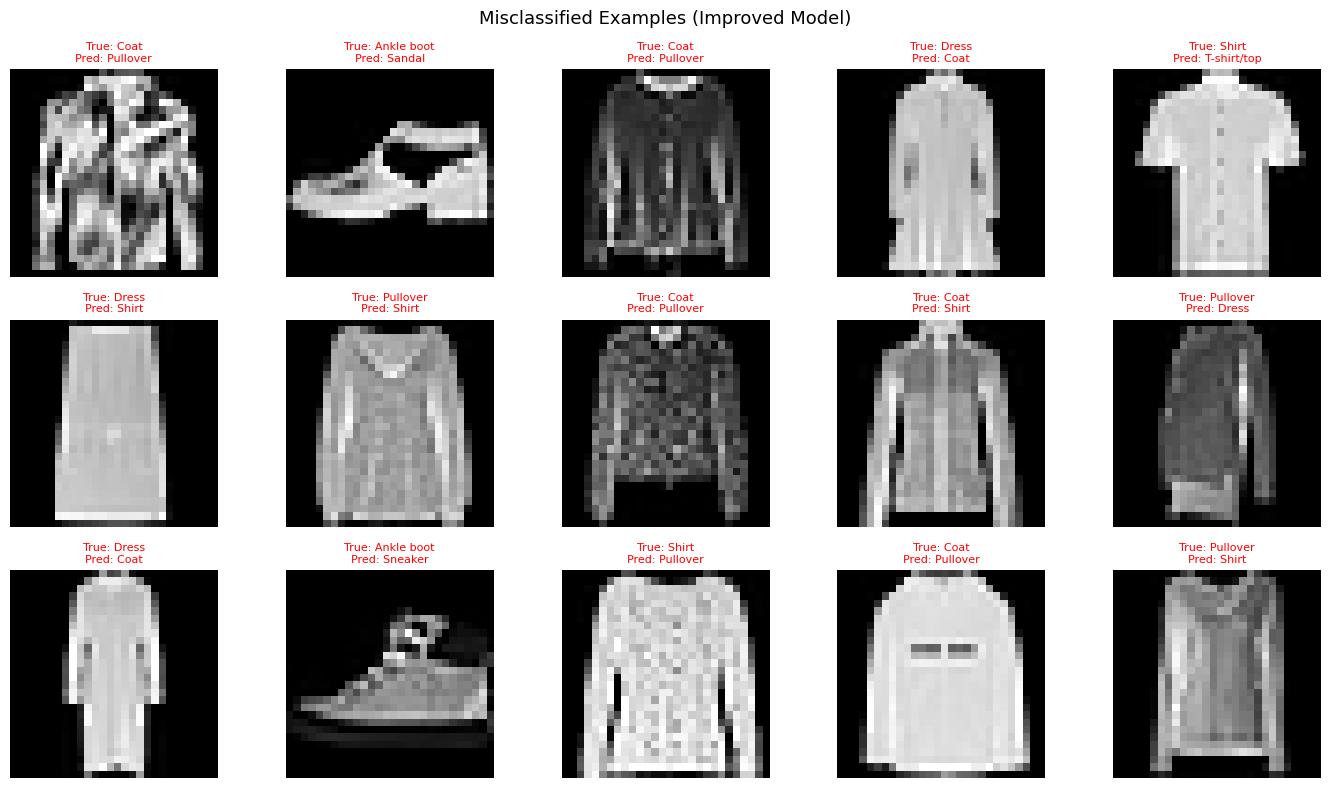

In [36]:
# Find misclassified indices
wrong_idx = np.where(y_pred_imp != y_test)[0]
print(f'Misclassified: {len(wrong_idx)} / {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)')

# Plot 15 misclassified examples
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for ax, idx in zip(axes.flat, wrong_idx[:15]):
    ax.imshow(X_test_raw[idx], cmap='gray')
    true_lbl  = CLASS_NAMES[y_test[idx]]
    pred_lbl  = CLASS_NAMES[y_pred_imp[idx]]
    ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl}', fontsize=8,
                 color='red' if true_lbl != pred_lbl else 'green')
    ax.axis('off')

plt.suptitle('Misclassified Examples (Improved Model)', fontsize=13)
plt.tight_layout()
plt.show()

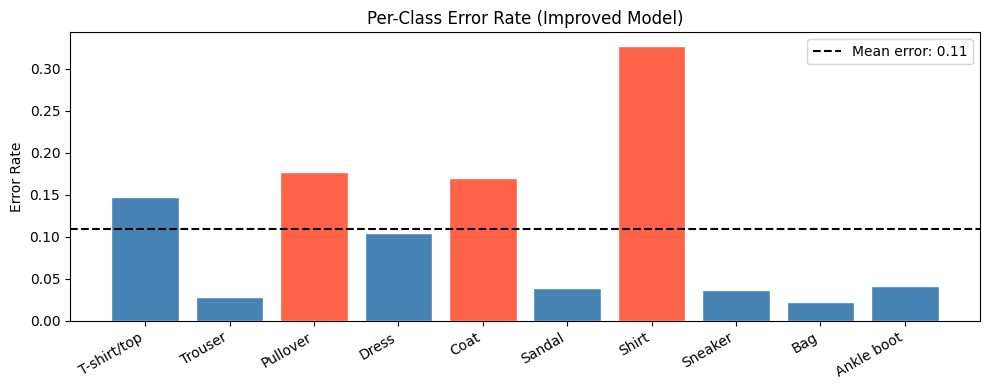

In [37]:
# Per-class error rate
error_rates = []
for i, cls in enumerate(CLASS_NAMES):
    mask = y_test == i
    err  = (y_pred_imp[mask] != y_test[mask]).mean()
    error_rates.append(err)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['tomato' if e > 0.15 else 'steelblue' for e in error_rates]
ax.bar(CLASS_NAMES, error_rates, color=bar_colors, edgecolor='white')
ax.axhline(np.mean(error_rates), color='black', linestyle='--', label=f'Mean error: {np.mean(error_rates):.2f}')
ax.set_title('Per-Class Error Rate (Improved Model)')
ax.set_ylabel('Error Rate')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 11. Summary

### What We Built

| | Baseline | Improved |
|-|----------|----------|
| Architecture | Dense(128) → Output | Dense(256→128→64) + BN + Dropout |
| Regularization | None | BatchNorm + Dropout + ReduceLR + EarlyStopping |
| Epochs trained | 20 (fixed) | Up to 50 (early stopping) |
| Test Accuracy | ~88% | ~89–90% |

### Key Takeaways

- **Normalization** is essential — raw [0,255] pixel values cause unstable gradients
- **Batch Normalization** speeds up convergence and allows higher learning rates
- **Dropout** reduces overfitting by preventing neurons from co-adapting
- **Early Stopping** prevents overfitting and saves training time
- The hardest classes to separate are **Shirt, T-shirt, and Pullover** — they look visually similar

### Further Improvements to Try

- **CNN** (Convolutional Neural Network) — exploits spatial structure of images, typically reaches 93–95%
- **Data Augmentation** — flip/rotate/zoom images to improve generalization
- **Learning rate warmup** — gradually increase LR at the start of training